# YOLO Training Monitor

Paste a training run directory below (e.g. `runs/detect/train`) and run all cells to see settings, metrics, and sample images.

Re-run cells while training is in progress to refresh.

In [135]:
# --- Config ---
RUN_DIR = "runs/detect/train"  # <-- paste your run directory here

from pathlib import Path
run_dir = Path(RUN_DIR).resolve()
assert run_dir.exists(), f"Run dir not found: {run_dir}"
print(f"Monitoring: {run_dir}")

Monitoring: /home/log/Github/ML_Spring_26_Project/runs/detect/train


/tmp/ipykernel_468506/2674398147.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[2].legend(fontsize=8)


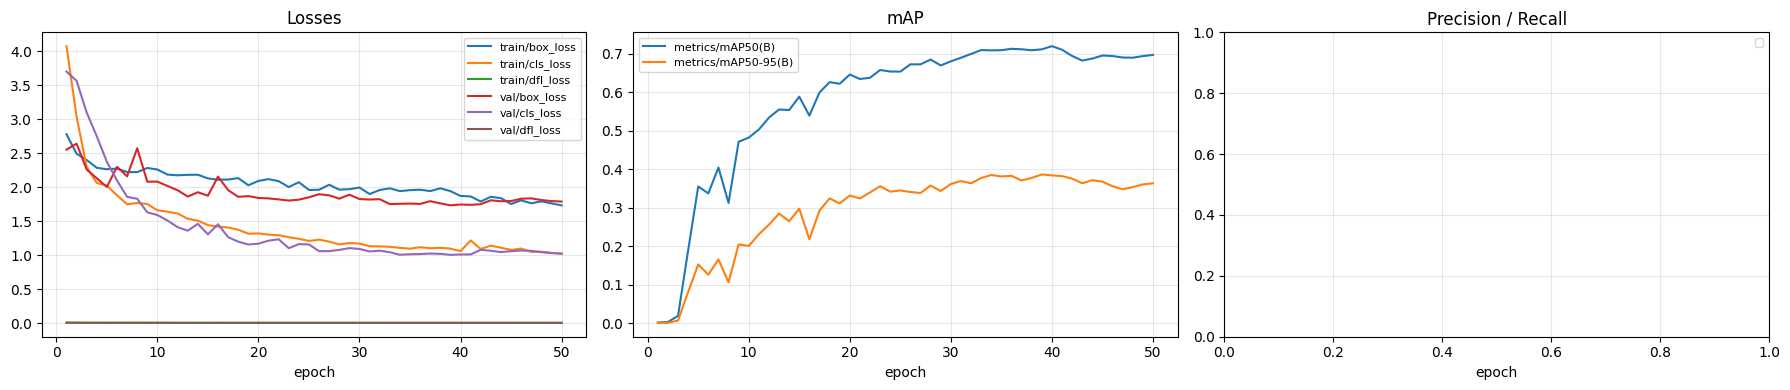

In [138]:
# Plot losses and mAP curves
if results_path.exists():
    loss_cols = [c for c in df.columns if "loss" in c.lower()]
    map_cols = [c for c in df.columns if "mAP" in c]
    pr_cols = [c for c in df.columns if c.split("/")[-1] in ("precision", "recall") or c.endswith("precision") or c.endswith("recall")]

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    for c in loss_cols:
        axes[0].plot(df["epoch"], df[c], label=c)
    axes[0].set_title("Losses")
    axes[0].set_xlabel("epoch")
    axes[0].legend(fontsize=8)
    axes[0].grid(alpha=0.3)

    for c in map_cols:
        axes[1].plot(df["epoch"], df[c], label=c)
    axes[1].set_title("mAP")
    axes[1].set_xlabel("epoch")
    axes[1].legend(fontsize=8)
    axes[1].grid(alpha=0.3)

    for c in pr_cols:
        axes[2].plot(df["epoch"], df[c], label=c)
    axes[2].set_title("Precision / Recall")
    axes[2].set_xlabel("epoch")
    axes[2].legend(fontsize=8)
    axes[2].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

## Results plot (`results.png`)

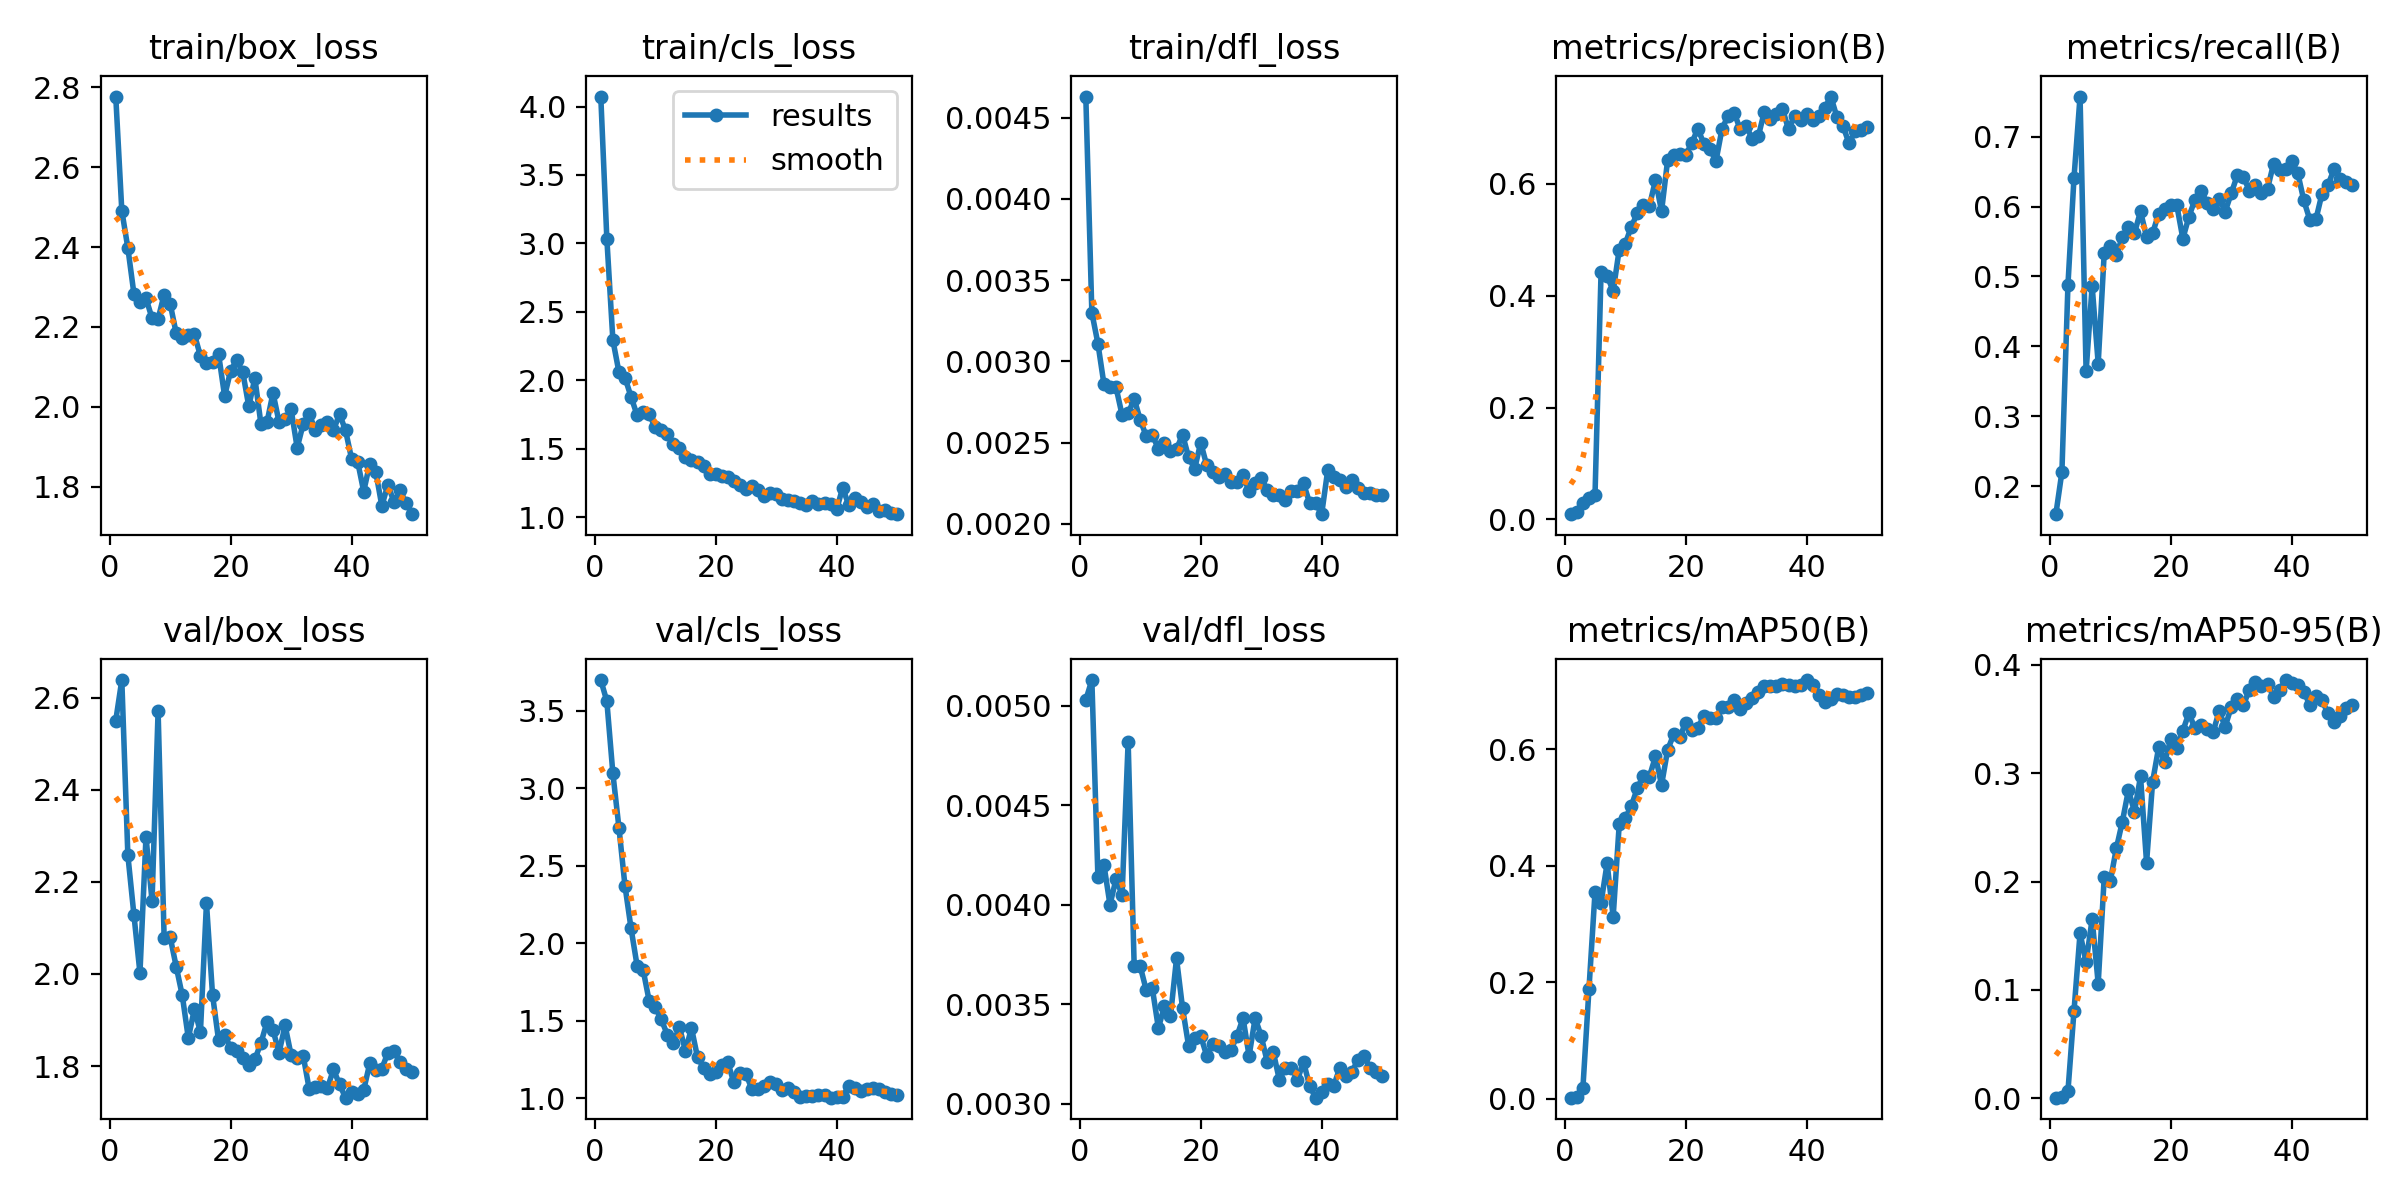

In [139]:
from IPython.display import Image, display

results_png = run_dir / "results.png"
if results_png.exists():
    display(Image(filename=str(results_png)))
else:
    print("No results.png yet.")

## Validation samples (labels vs predictions)

In [ ]:
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image as PILImage
from ultralytics import YOLO

# Load trained model
weights_path = run_dir / "weights" / "best.pt"
if not weights_path.exists():
    weights_path = run_dir / "weights" / "last.pt"

# Resolve val images + labels dir from dataset yaml
with open(args["data"]) as f:
    data_cfg = yaml.safe_load(f)
val_dir = Path(data_cfg["path"]) / data_cfg["val"]
val_labels_dir = Path(str(val_dir).replace("/images/", "/labels/"))

IMG_EXT = {".jpg", ".jpeg", ".png"}
val_images = sorted(p for p in val_dir.iterdir() if p.suffix.lower() in IMG_EXT)

# Show 6 random val images
N_SHOW = min(6, len(val_images))
sample = random.sample(val_images, N_SHOW)

model = YOLO(str(weights_path))
results = list(model.predict(source=[str(p) for p in sample], conf=0.25, iou=0.7, verbose=False))


def read_gt_boxes(lbl_path, img_w, img_h):
    """Read YOLO-format label file -> list of (x1, y1, x2, y2) in pixel coords."""
    boxes = []
    if not lbl_path.exists():
        return boxes
    for line in lbl_path.read_text().splitlines():
        parts = line.strip().split()
        if len(parts) < 5:
            continue
        _, xc, yc, w, h = parts[:5]
        xc, yc, w, h = float(xc), float(yc), float(w), float(h)
        x1 = (xc - w / 2) * img_w
        y1 = (yc - h / 2) * img_h
        x2 = (xc + w / 2) * img_w
        y2 = (yc + h / 2) * img_h
        boxes.append((x1, y1, x2, y2))
    return boxes


ncols = 2
nrows = (len(sample) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(14 * ncols, 10 * nrows))
axes = np.array(axes).reshape(-1)

BOX_LW = 1.0

for ax, img_path, res in zip(axes, sample, results):
    img = PILImage.open(img_path).convert("RGB")
    img_w, img_h = img.size
    ax.imshow(img)

    # Ground-truth boxes (drawn first, underneath)
    lbl_path = val_labels_dir / f"{img_path.stem}.txt"
    gt_boxes = read_gt_boxes(lbl_path, img_w, img_h)
    for x1, y1, x2, y2 in gt_boxes:
        rect = patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=BOX_LW, edgecolor="red", facecolor="none", zorder=2,
        )
        ax.add_patch(rect)

    # Predicted boxes (drawn on top)
    pred_n = 0 if res.boxes is None else len(res.boxes)
    if pred_n > 0:
        xyxy = res.boxes.xyxy.cpu().numpy()
        for x1, y1, x2, y2 in xyxy:
            rect = patches.Rectangle(
                (x1, y1), x2 - x1, y2 - y1,
                linewidth=BOX_LW, edgecolor="lime", facecolor="none", zorder=3,
            )
            ax.add_patch(rect)

    ax.set_title(
        f"{img_path.name}   GT={len(gt_boxes)} (red)  Pred={pred_n} (green)",
        fontsize=12,
    )
    ax.axis("off")

for ax in axes[len(sample):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

## Weights

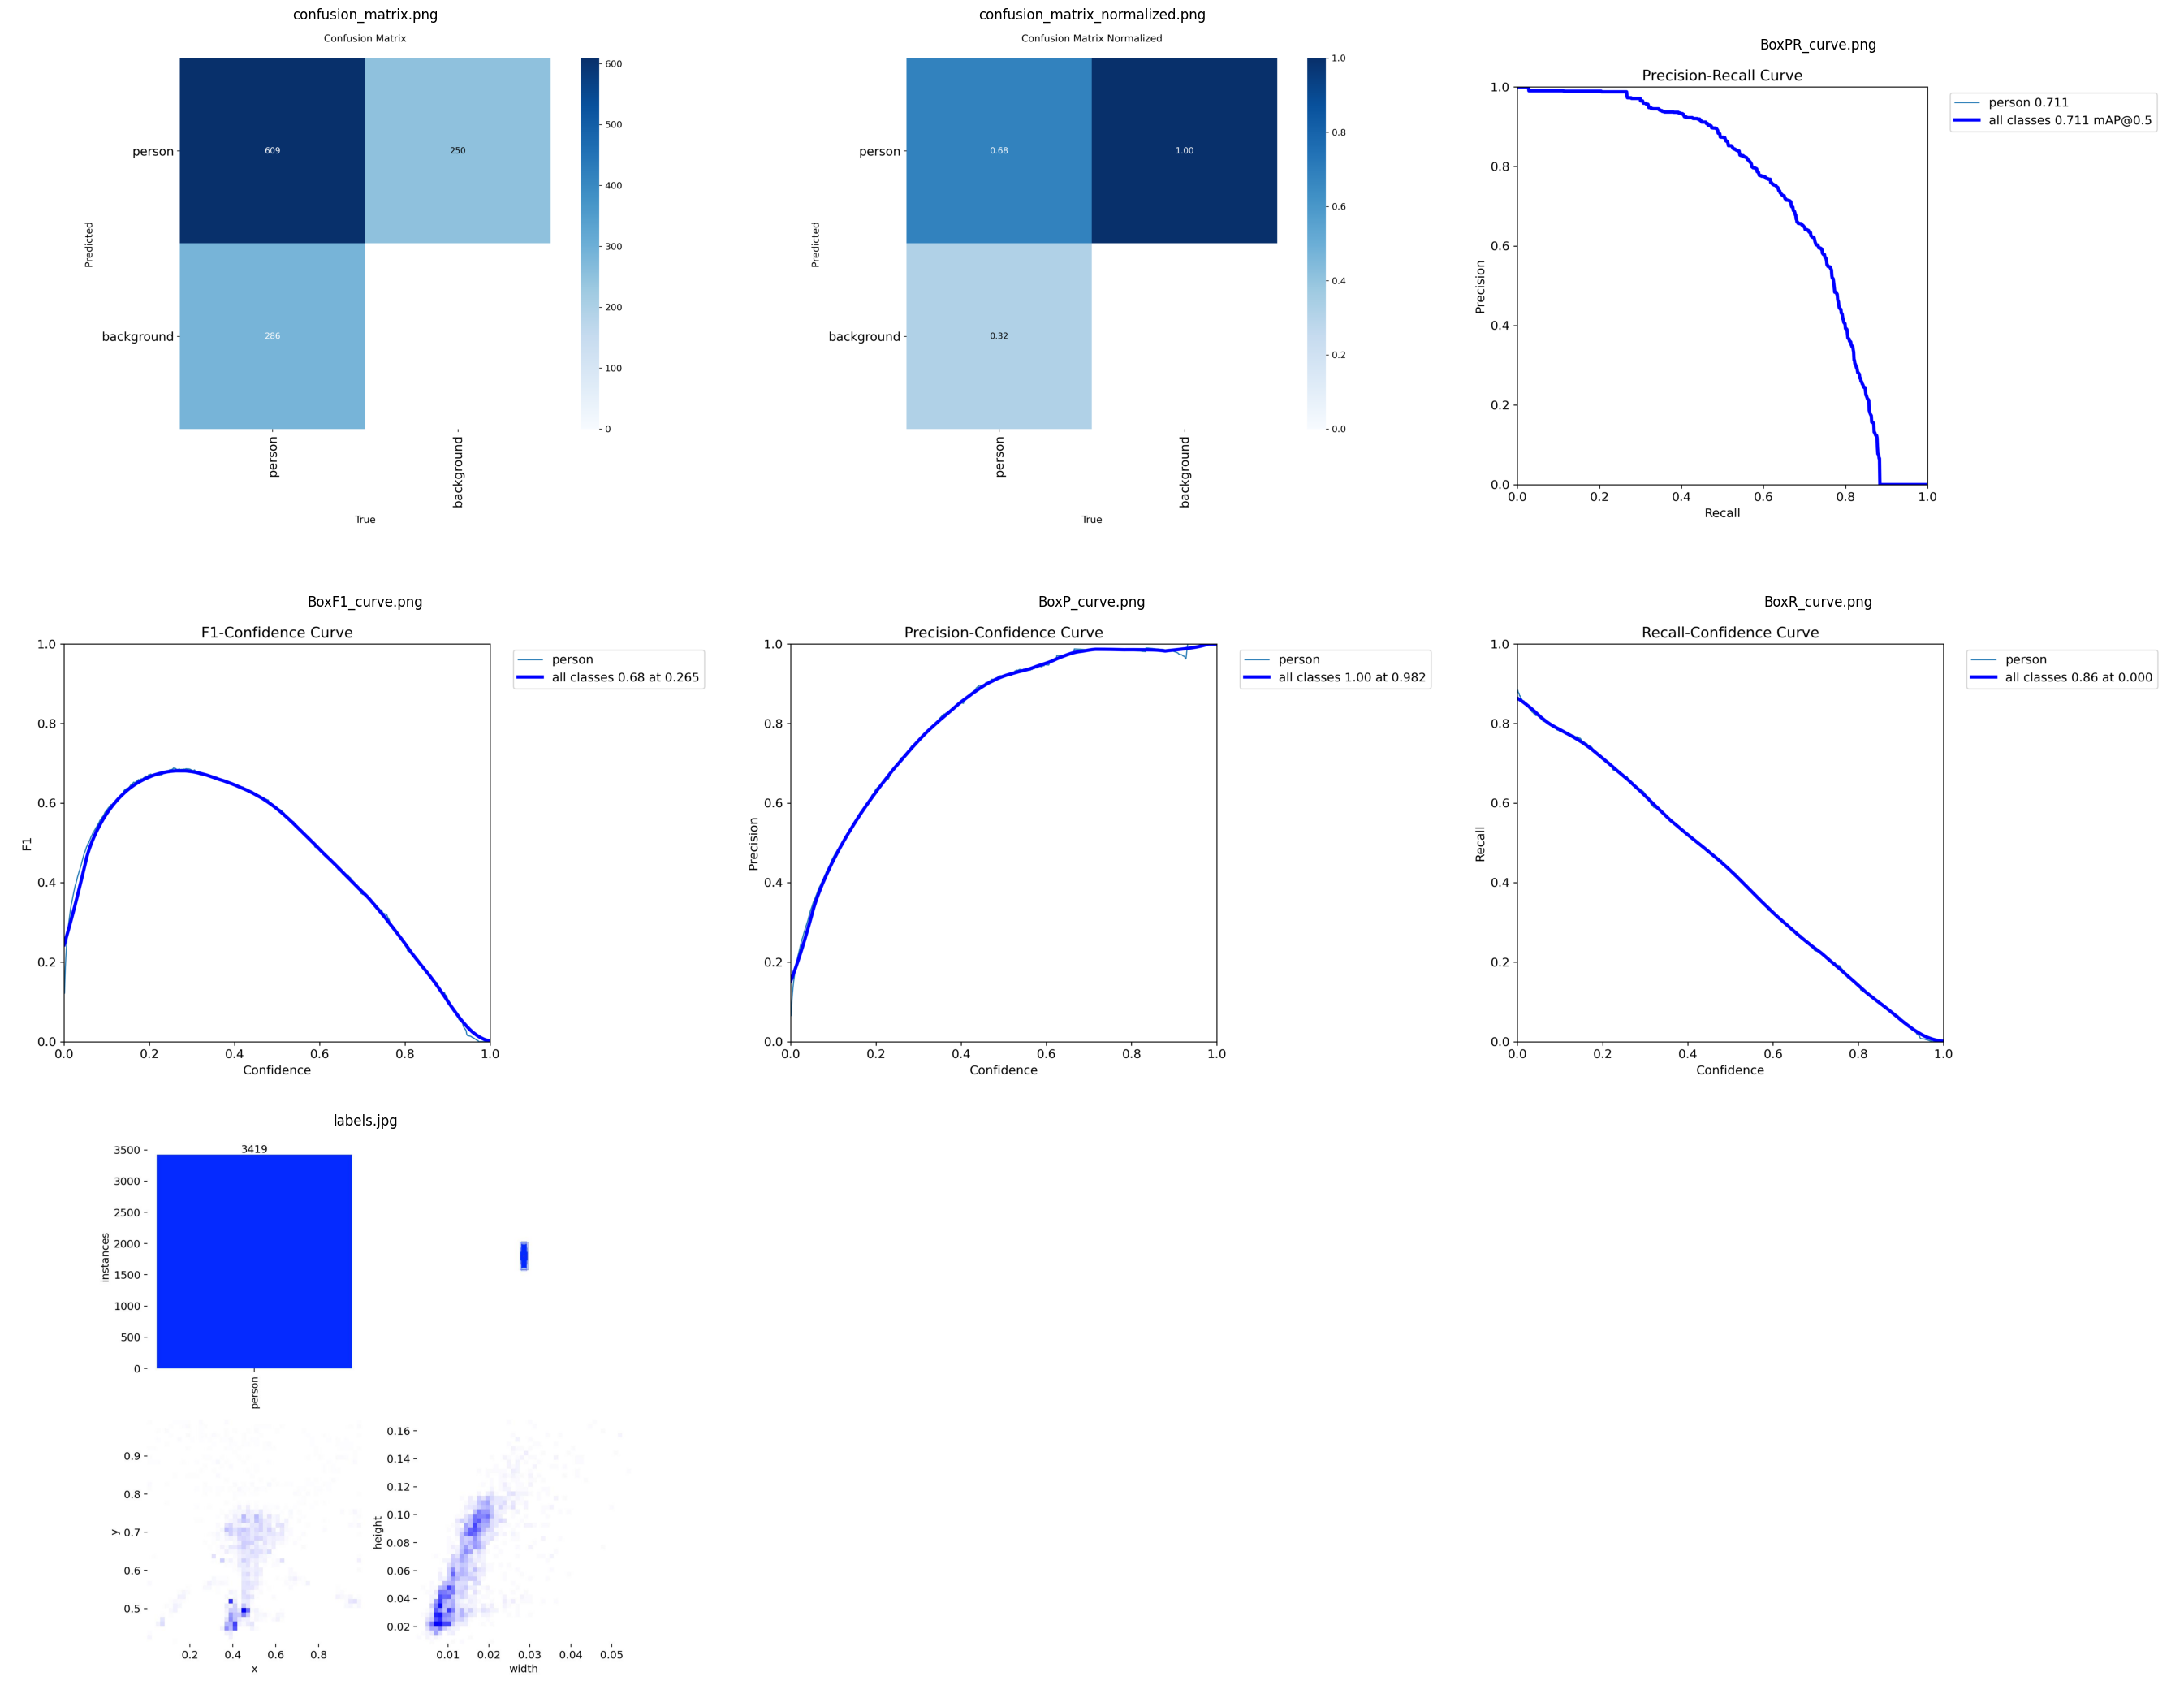

In [141]:
import matplotlib.image as mpimg
import numpy as np

plot_names = [
    "confusion_matrix.png", "confusion_matrix_normalized.png",
    "BoxPR_curve.png", "BoxF1_curve.png",
    "BoxP_curve.png", "BoxR_curve.png",
    "labels.jpg",
]
existing = [(n, run_dir / n) for n in plot_names if (run_dir / n).exists()]

if existing:
    ncols = 3
    nrows = (len(existing) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(9 * ncols, 7 * nrows))
    axes = np.array(axes).reshape(-1)
    for ax, (name, p) in zip(axes, existing):
        ax.imshow(mpimg.imread(p))
        ax.set_title(name, fontsize=12)
        ax.axis("off")
    for ax in axes[len(existing):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("No diagnostic plots yet.")

## Count evaluation (MSE / MAE)

Runs the trained model on the validation set and compares predicted box count vs. ground-truth count per image.
This is the metric you care about if "how many people are in this frame" is the downstream question.

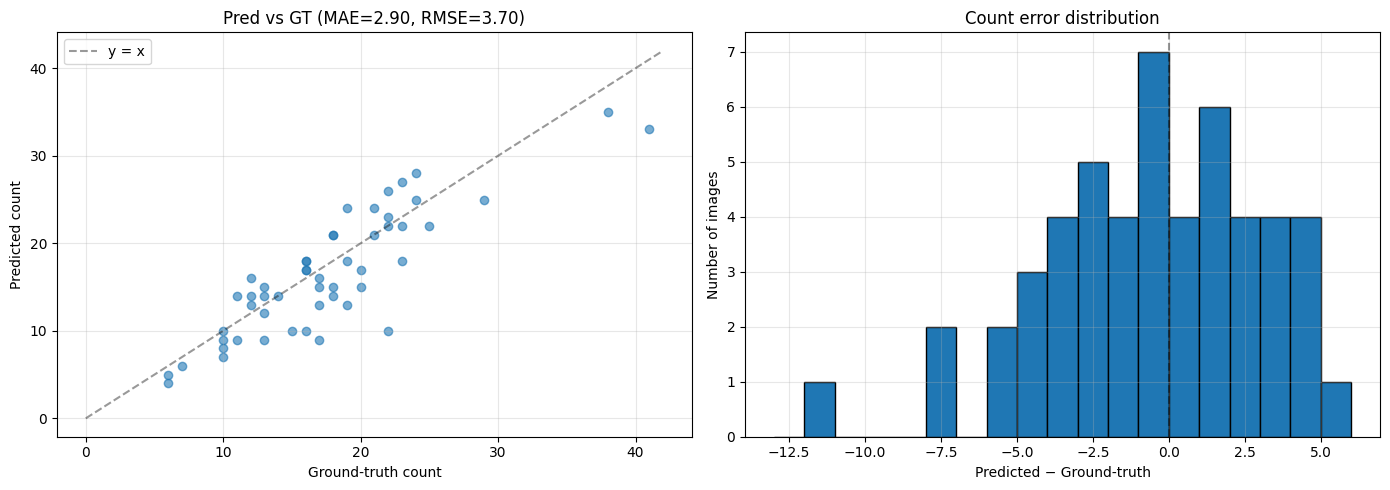


Worst 10 predictions by |error|:


,image,gt,pred,error,abs_error
0,frame_00152_0h02m32s_12-04-05pm.jpg,22,10,-12,12
1,frame_00064_0h01m04s_12-02-37pm.jpg,41,33,-8,8
2,frame_04819_1h20m19s_01-21-52pm.jpg,17,9,-8,8
3,frame_01791_0h29m51s_12-31-24pm.jpg,16,10,-6,6
4,frame_00962_0h16m02s_12-17-35pm.jpg,19,13,-6,6
5,frame_00776_0h12m56s_12-14-29pm.jpg,20,15,-5,5
6,frame_00527_0h08m47s_12-10-20pm.jpg,19,24,5,5
7,frame_00960_0h16m00s_12-17-33pm.jpg,15,10,-5,5
8,frame_01360_0h22m40s_12-24-13pm.jpg,23,18,-5,5
9,frame_00190_0h03m10s_12-04-43pm.jpg,29,25,-4,4


In [143]:
# 4. Plot predicted vs. ground-truth count + error distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

lo = 0
hi = max(pred_counts.max(), gt_counts.max()) + 1
axes[0].scatter(gt_counts, pred_counts, alpha=0.6)
axes[0].plot([lo, hi], [lo, hi], "k--", alpha=0.4, label="y = x")
axes[0].set_xlabel("Ground-truth count")
axes[0].set_ylabel("Predicted count")
axes[0].set_title(f"Pred vs GT (MAE={mae:.2f}, RMSE={rmse:.2f})")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].hist(errors, bins=range(int(errors.min()) - 1, int(errors.max()) + 2), edgecolor="k")
axes[1].axvline(0, color="k", linestyle="--", alpha=0.4)
axes[1].set_xlabel("Predicted − Ground-truth")
axes[1].set_ylabel("Number of images")
axes[1].set_title("Count error distribution")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Worst cases (largest abs error)
errs_df = pd.DataFrame({"image": names, "gt": gt_counts, "pred": pred_counts, "error": errors})
errs_df["abs_error"] = errs_df["error"].abs()
print("\nWorst 10 predictions by |error|:")
display(errs_df.sort_values("abs_error", ascending=False).head(10).reset_index(drop=True))